# 0. Load in the cleaned test data

In [28]:
import pandas as pd

test = pd.read_csv("/Users/nick/Library/CloudStorage/OneDrive-Personal/Programming projects/Team Union/Nick/churn_test_cleaned.csv")
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1739 entries, 0 to 1738
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   GuestID                1739 non-null   int64  
 1   AllInclusive           1690 non-null   float64
 2   VIP                    1694 non-null   float64
 3   RoomService            1627 non-null   float64
 4   Dining                 1614 non-null   float64
 5   Retail                 1700 non-null   float64
 6   Spa                    1707 non-null   float64
 7   Entertainment          1695 non-null   float64
 8   LoyaltyPoints          1739 non-null   int64  
 9   SurveyScore            1739 non-null   int64  
 10  DaysSinceEmail         1739 non-null   int64  
 11  SharedRoom             1739 non-null   int64  
 12  PromoCodeUsed          1739 non-null   int64  
 13  DaysSinceEmail_Decile  1739 non-null   int64  
dtypes: float64(7), int64(7)
memory usage: 190.3 KB


# 1. Train the model - This is where your model goes

In [29]:
df3 = pd.read_csv("/Users/nick/Library/CloudStorage/OneDrive-Personal/Programming projects/Team Union/Nick/churn_full_cleaned_numbers.csv")
df3.info()

from sklearn.model_selection import train_test_split

X = df3.drop('Churned', axis=1)
y = df3['Churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6954 entries, 0 to 6953
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   GuestID                6954 non-null   int64  
 1   AllInclusive           6786 non-null   float64
 2   VIP                    6796 non-null   float64
 3   RoomService            6490 non-null   float64
 4   Dining                 6466 non-null   float64
 5   Retail                 6790 non-null   float64
 6   Spa                    6806 non-null   float64
 7   Entertainment          6815 non-null   float64
 8   LoyaltyPoints          6954 non-null   int64  
 9   SurveyScore            6954 non-null   int64  
 10  DaysSinceEmail         6954 non-null   int64  
 11  Churned                6954 non-null   int64  
 12  SharedRoom             6954 non-null   int64  
 13  PromoCodeUsed          6954 non-null   int64  
 14  DaysSinceEmail_Decile  6954 non-null   int64  
dtypes: f

Test ROC-AUC:        0.853
Best iteration:      143


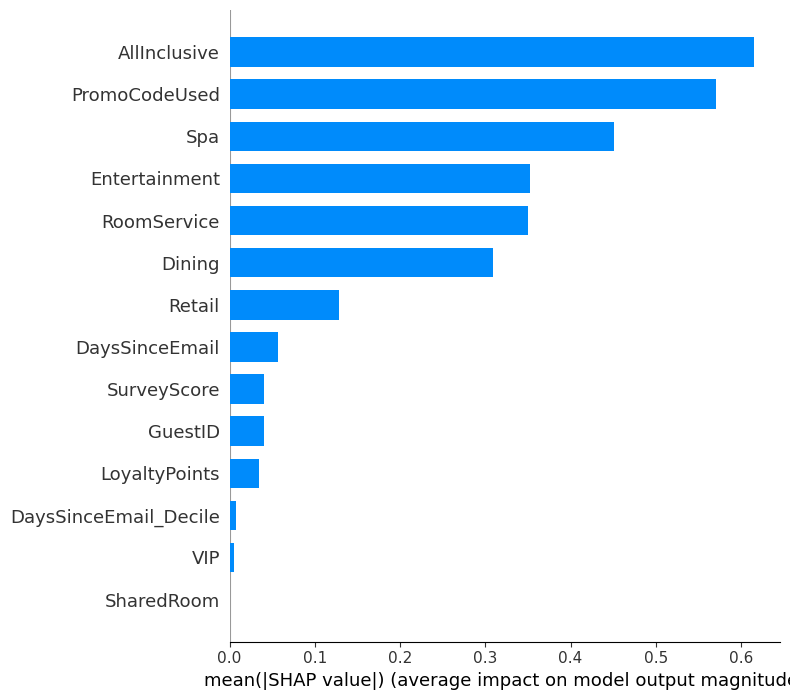

In [30]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import shap

# Class imbalance: scale_pos_weight ≈ neg / pos in your training data
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    scale_pos_weight=neg / pos,
    eval_metric="auc",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

probs = xgb.predict_proba(X_test)[:, 1]
print(f"Test ROC-AUC:        {roc_auc_score(y_test, probs):.3f}")
print(f"Best iteration:      {xgb.best_iteration}")

# Explain individual predictions with SHAP — critical for stakeholder trust
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

# 2. Test - This will produce the test data

In [31]:
#run the test data against the model to get the probabilities for the submission file

probs = xgb.predict(test)

#display the probs
print(probs)

#remove all columns except for the GuestID column and then add the probabilities as a new column called "Churned"
submission = test[["GuestID"]].copy()
submission["Churned"] = probs

submission.info()

#output the csv file with the predictions
submission.to_csv("submission.csv", index=False)

[1 1 0 ... 1 0 0]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1739 entries, 0 to 1738
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   GuestID  1739 non-null   int64
 1   Churned  1739 non-null   int64
dtypes: int64(2)
memory usage: 27.3 KB
